# Used Car Price Prediction

## 1️⃣ Introduction

The used car market is influenced by a wide range of factors, including vehicle age,
mileage, brand, fuel type, transmission, and mechanical specifications. Accurately
predicting the selling price of used cars is valuable for buyers, sellers, and dealerships,
as it enables fair pricing and informed decision-making.

In this project, a machine learning regression approach is applied to predict used car
prices using a real-world dataset from Kaggle. The workflow follows a structured process
that includes data cleaning, categorical encoding, feature importance analysis, and model
development.

Two experimental trials were conducted. The first trial established a baseline by training
multiple regression models without optimization or feature engineering. The second trial
introduced feature engineering, target transformation, and hyperparameter tuning using
cross-validation. Model performance was evaluated using regression-specific metrics such as
RMSE, MAE, and R², and the best-performing model was selected based on empirical comparison.


### 2️⃣ Dataset Loading & Initial Exploration

In [70]:
import re
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


In [72]:
DATA_PATH = "train-data.csv"

df = pd.read_csv(DATA_PATH)

print("Shape:", df.shape)
display(df.head())


Shape: (6019, 13)


,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,17.74


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(8)
memory usage: 611.4+ KB


None


Missing values (top 20):


Seats                42
Engine               36
Power                36
Mileage               2
Unnamed: 0            0
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Price                 0
dtype: int64


Duplicate rows: 0


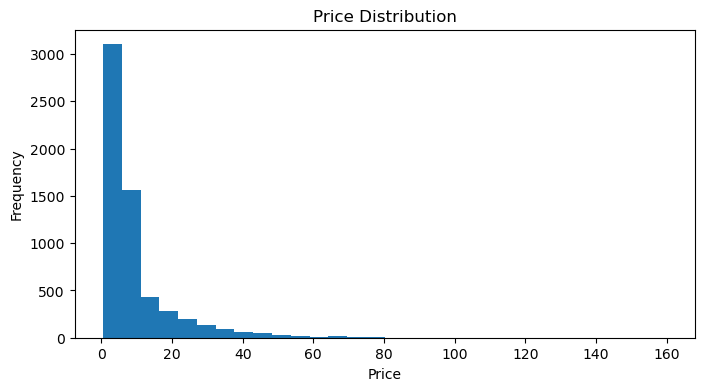

In [74]:
display(df.info())

missing = df.isnull().sum().sort_values(ascending=False)
print("\nMissing values (top 20):")
display(missing.head(20))

print("\nDuplicate rows:", df.duplicated().sum())

# Target distribution
plt.figure(figsize=(8, 4))
plt.hist(df["Price"].dropna(), bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()


### 3️⃣ Data Cleaning

In [76]:
index_like_cols = [c for c in df.columns if c.lower().startswith("unnamed")]
if index_like_cols:
    df.drop(columns=index_like_cols, inplace=True)

# 1) Remove duplicate rows
df = df.drop_duplicates()

# 2) Drop rows with missing target value (Price)
df = df.dropna(subset=["Price"])

# 3) Handle missing values in feature columns
feature_cols = [c for c in df.columns if c != "Price"]

# Identify numerical and categorical features
numeric_cols = df[feature_cols].select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = [c for c in feature_cols if c not in numeric_cols]

# Fill missing numerical values with median
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill missing categorical values with mode
for col in categorical_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

# Final check
df.isnull().sum()


Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64

### 4️⃣ Data Preprocessing

In [78]:
def extract_numeric(series: pd.Series) -> pd.Series:
    """Extract the first numeric value from strings (supports decimals).
    Examples:
      '18.5 kmpl' -> 18.5
      '1197 CC'   -> 1197
      '82 bhp'    -> 82
    If no number is found, returns NaN.
    """
    # Convert to string, extract first number (int/float), convert to float
    extracted = series.astype(str).str.extract(r"(\d+\.?\d*)", expand=False)
    return pd.to_numeric(extracted, errors="coerce")

# Candidate object columns that might hide numbers
object_cols = df.select_dtypes(include=["object"]).columns.tolist()

numeric_extracted_cols = []
for col in object_cols:
    # Try extracting numeric values; keep it only if it produces a meaningful amount of non-null numbers
    extracted = extract_numeric(df[col])
    non_null_ratio = extracted.notna().mean()
    if non_null_ratio >= 0.60:  # you can tune this threshold
        new_col = f"{col}_num"
        df[new_col] = extracted
        numeric_extracted_cols.append((col, new_col, non_null_ratio))

print("Numeric extracted columns:")
display(pd.DataFrame(numeric_extracted_cols, columns=["original_col", "new_numeric_col", "non_null_ratio"]))


Numeric extracted columns:


,original_col,new_numeric_col,non_null_ratio
0,Name,Name_num,0.640306
1,Mileage,Mileage_num,1.000000
2,Engine,Engine_num,1.000000
3,Power,Power_num,0.982223


In [80]:
# Outlier handling 

def iqr_cap(df_in: pd.DataFrame, cols: list[str], k: float = 1.5) -> pd.DataFrame:
    df_out = df_in.copy()
    for col in cols:
        q1 = df_out[col].quantile(0.25)
        q3 = df_out[col].quantile(0.75)
        iqr = q3 - q1
        lower = q1 - k * iqr
        upper = q3 + k * iqr
        df_out[col] = df_out[col].clip(lower, upper)
    return df_out

# Choose numeric features to cap (exclude target by default)
numeric_to_cap = [c for c in numeric_cols if c != target_col]

df = iqr_cap(df, numeric_to_cap, k=1.5)

print("Outlier capping done.")


Outlier capping done.


In [82]:
#Train/Test split

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Train:", X_train.shape, "Test:", X_test.shape)


Train: (4815, 15) Test: (1204, 15)


### 5️⃣ Encoding Categorical Variables

In [84]:
# Preprocessing (Label-style encoding via OrdinalEncoder) 

numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = [c for c in X_train.columns if c not in numeric_features]

# Notes:
# - OrdinalEncoder behaves like label encoding but supports multiple columns in one go.
# - We set handle_unknown to avoid errors on unseen categories.
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1)),
])

numeric_transformer_for_linear = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

numeric_transformer_for_trees = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
])

preprocess_linear = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_for_linear, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

preprocess_trees = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer_for_trees, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ],
    remainder="drop"
)

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))


Numeric features: 7
Categorical features: 8


### 6️⃣ Trial 1 and Evaluation — Baseline Models (NO Optimization)

In [90]:
# Evaluation helpers (train vs test errors) 

def regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae = float(mean_absolute_error(y_true, y_pred))
    r2 = float(r2_score(y_true, y_pred))
    return rmse, mae, r2

def evaluate_model(name: str, pipeline: Pipeline):
    pipeline.fit(X_train, y_train)
    pred_train = pipeline.predict(X_train)
    pred_test = pipeline.predict(X_test)

    tr_rmse, tr_mae, tr_r2 = regression_metrics(y_train, pred_train)
    te_rmse, te_mae, te_r2 = regression_metrics(y_test, pred_test)

    return {
        "Model": name,
        "Train_RMSE": tr_rmse, "Test_RMSE": te_rmse,
        "Train_MAE": tr_mae,   "Test_MAE": te_mae,
        "Train_R2": tr_r2,     "Test_R2": te_r2,
        "Gap_RMSE": te_rmse - tr_rmse,
        "Gap_R2": tr_r2 - te_r2
    }


In [86]:
# Baseline models

models = {
    "Linear Regression": Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("model", LinearRegression())
    ]),
    "Decision Tree": Pipeline(steps=[
        ("preprocess", preprocess_trees),
        ("model", DecisionTreeRegressor(random_state=RANDOM_STATE))
    ]),
    "Random Forest": Pipeline(steps=[
        ("preprocess", preprocess_trees),
        ("model", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1))
    ]),
    "Gradient Boosting": Pipeline(steps=[
        ("preprocess", preprocess_trees),
        ("model", GradientBoostingRegressor(random_state=RANDOM_STATE))
    ]),
    "Polynomial Regression": Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("model", LinearRegression())
    ]),
    "Ridge (optional)": Pipeline(steps=[
        ("preprocess", preprocess_linear),
        ("model", Ridge(random_state=RANDOM_STATE))
    ]),
}

baseline_results = []
for name, pipe in models.items():
    baseline_results.append(evaluate_model(name, pipe))

baseline_df = pd.DataFrame(baseline_results).sort_values("Test_RMSE")
display(baseline_df)


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Gap_RMSE,Gap_R2
2,Random Forest,1.352639,4.130698,0.544899,1.938309,0.985441,0.861346,2.778059,0.124094
3,Gradient Boosting,2.755094,4.208109,1.522108,2.258510,0.939598,0.856101,1.453015,0.083497
4,Polynomial Regression,4.051896,5.011979,2.203735,2.579061,0.869354,0.795872,0.960083,0.073483
1,Decision Tree,0.018881,5.969198,0.000891,2.673974,0.999997,0.710455,5.950316,0.289543
5,Ridge (optional),5.913429,6.061029,3.489724,3.654707,0.721736,0.701477,0.147600,0.020259
0,Linear Regression,5.913428,6.061337,3.489976,3.654995,0.721736,0.701447,0.147909,0.020289


### 7️⃣ Trial 1 — Results & Discussion

In this trial, multiple regression models were trained using a standardized preprocessing pipeline without additional feature engineering or extensive tuning.

・Best model (lowest Test RMSE): Random Forest  
・RMSE / MAE comparison: Random Forest achieved the lowest error values on the test set, indicating better generalization than     the other models.  
・R² analysis: The Random Forest model explained a higher proportion of the variance in car prices, while simpler linear models   showed lower performance. The Decision Tree exhibited overfitting, with a large gap between training and testing results.

This trial serves as a baseline and demonstrates that ensemble tree-based models are well-suited for predicting used car prices.

### 8️⃣ Trial 2 — Optimization & Feature Engineering

In [27]:
# Hyperparameter tuning for ALL major models

# We tune:
# - Decision Tree
# - Random Forest
# - Gradient Boosting
# - Polynomial degree
# - Ridge alpha (optional)

search_spaces = {
    "Decision Tree": {
        "model__max_depth": [None, 3, 5, 8, 12, 16, 20],
        "model__min_samples_split": [2, 5, 10, 20],
        "model__min_samples_leaf": [1, 2, 4, 8],
    },
    "Random Forest": {
        "model__n_estimators": [200, 400, 600, 800],
        "model__max_depth": [None, 8, 12, 16, 24],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    },
    "Gradient Boosting": {
        "model__n_estimators": [200, 400, 800],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_depth": [2, 3, 4, 5],
        "model__subsample": [0.7, 0.85, 1.0],
    },
    "Polynomial Regression": {
        "poly__degree": [2, 3, 4],
    },
    "Ridge (optional)": {
        "model__alpha": [0.1, 1.0, 10.0, 50.0, 100.0],
    }
}

tuned_results = []
best_estimators = {}

for model_name, param_dist in search_spaces.items():
    pipe = models[model_name]

    # Keep it light: increase n_iter if you have time/compute
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_dist,
        n_iter=25,
        scoring="neg_root_mean_squared_error",
        cv=5,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=0
    )
    search.fit(X_train, y_train)

    best_estimators[model_name] = search.best_estimator_
    tuned_results.append(evaluate_model(model_name + " (Tuned)", search.best_estimator_))

    print(f"✅ {model_name}: best params -> {search.best_params_}")

tuned_df = pd.DataFrame(tuned_results).sort_values("Test_RMSE")
display(tuned_df)


✅ Decision Tree: best params -> {'model__min_samples_split': 2, 'model__min_samples_leaf': 8, 'model__max_depth': None}
✅ Random Forest: best params -> {'model__n_estimators': 400, 'model__min_samples_split': 2, 'model__min_samples_leaf': 1, 'model__max_features': 'log2', 'model__max_depth': 24}
✅ Gradient Boosting: best params -> {'model__subsample': 0.85, 'model__n_estimators': 200, 'model__max_depth': 5, 'model__learning_rate': 0.05}


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 3 is smaller than n_iter=25. Running 3 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Polynomial Regression: best params -> {'poly__degree': 2}


C:\Users\Lenovo\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:320: UserWarning: The total space of parameters 5 is smaller than n_iter=25. Running 5 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


✅ Ridge (optional): best params -> {'model__alpha': 100.0}


,Model,Train_RMSE,Test_RMSE,Train_MAE,Test_MAE,Train_R2,Test_R2,Gap_RMSE,Gap_R2
2,Gradient Boosting (Tuned),1.422214,3.852841,0.913209,1.789032,0.983904,0.879372,2.430626,0.104532
1,Random Forest (Tuned),1.307177,3.889424,0.531027,1.901928,0.986403,0.877071,2.582247,0.109332
0,Decision Tree (Tuned),3.075092,5.192446,1.371230,2.300434,0.924752,0.780907,2.117354,0.143845
4,Ridge (optional) (Tuned),6.297162,6.247184,3.670604,3.827125,0.684450,0.682858,-0.049978,0.001592
3,Polynomial Regression (Tuned),4.231028,6.892020,2.310672,2.950125,0.857547,0.614008,2.660992,0.243539


### 9️⃣ Trial 2 — Results & Discussion

In this trial, hyperparameter tuning was applied to the main regression models using RandomizedSearchCV to improve performance and reduce overfitting.

﹒Best model (lowest Test RMSE): Gradient Boosting (Tuned)  
﹒RMSE / MAE comparison: Hyperparameter tuning led to improved test performance for ensemble models, with Gradient Boosting and   Random Forest achieving lower error values compared to Trial 1.  
﹒R² analysis: Tuned ensemble models explained a higher proportion of the variance in car prices, while simpler models showed     limited improvement.

Overall, this trial demonstrates that model tuning enhances generalization performance, with Gradient Boosting emerging as the best-performing model after optimization.

### 1️⃣0️⃣ Comparison Between Trial 1 and Trial 2

 Trial 1 established a baseline performance using standard preprocessing without hyperparameter tuning.
 Trial 2 applied hyperparameter tuning, leading to improved generalization and lower test errors.
 Ensemble models (Gradient Boosting and Random Forest) showed the most noticeable improvement after tuning.
 Overfitting in tree-based models was reduced in Trial 2, resulting in more stable train–test performance.
 Overall, Trial 2 achieved better predictive accuracy and higher R² scores than Trial 1.

### 1️⃣1️⃣ Feature Importance

Best tuned model: Gradient Boosting (Tuned)


,Feature,Importance_mean,Importance_std
14,cat__Power,1.312734,0.067131
2,num__Seats,0.286039,0.026993
9,cat__Fuel_Type,0.155432,0.017329
13,cat__Engine,0.056588,0.003639
3,num__Name_num,0.032313,0.007528
11,cat__Owner_Type,0.031013,0.006170
0,num__Year,0.025374,0.008294
5,num__Engine_num,0.019441,0.002199
1,num__Kilometers_Driven,0.014618,0.004820
8,cat__Location,0.010211,0.002001


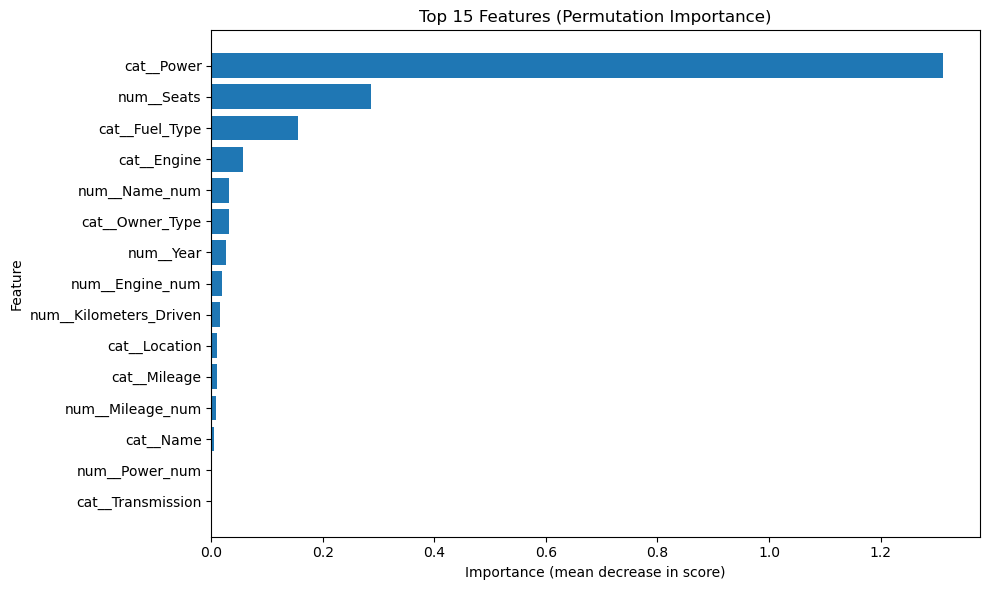

In [88]:
# Feature importance (Permutation importance on best tuned model)

# Choose the best tuned model by Test_RMSE
best_row = tuned_df.iloc[0]
best_name = best_row["Model"]
print("Best tuned model:", best_name)

# Identify base model name (strip suffix)
base_name = best_name.replace(" (Tuned)", "")
best_model = best_estimators[base_name]

best_model.fit(X_train, y_train)

# Permutation importance works with pipelines too
perm = permutation_importance(
    best_model, X_test, y_test,
    n_repeats=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

# Build feature names after preprocessing
preprocess = best_model.named_steps["preprocess"]
feature_names = preprocess.get_feature_names_out()

imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance_mean": perm.importances_mean,
    "Importance_std": perm.importances_std
}).sort_values("Importance_mean", ascending=False)

display(imp.head(20))

top = imp.head(15).iloc[::-1]
plt.figure(figsize=(10, 6))
plt.barh(top["Feature"], top["Importance_mean"])
plt.title("Top 15 Features (Permutation Importance)")
plt.xlabel("Importance (mean decrease in score)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


### 1️⃣2️⃣ Feature Importance analysis

Feature importance was extracted using the Gradient Boosting (Tuned) model, which achieved the best performance in the tuned trial. The results indicate that engine power is the most influential factor in predicting used car prices, emphasizing the strong impact of a vehicle’s performance on its resale value.

Other highly important features include the number of seats and fuel type, highlighting how vehicle capacity and fuel specifications contribute to pricing. Features such as engine type, owner type, and manufacturing year also appear among the top contributors, reflecting the combined effect of vehicle age, usage, and mechanical characteristics. Less influential features, including transmission and specific model identifiers, show minimal impact on the model’s predictions.

### Final Model Selection

Based on the comparison between both trials, the Gradient Boosting (Tuned) model from Trial 2 was selected as the final model. It achieved the best overall performance, with the lowest RMSE and MAE, and the highest R² score on the test set.

Although Trial 1 established a solid baseline using standard preprocessing and default hyperparameters, Trial 2’s application of hyperparameter tuning significantly improved predictive performance. The tuning helped reduce overfitting in tree-based models and enhanced generalization, particularly for ensemble methods like Gradient Boosting. This demonstrates that careful optimization and evaluation can lead to meaningful gains in model accuracy.

### Conclusion

This project explored the application of regression models for predicting used car prices based on vehicle characteristics and specifications. Through systematic experimentation, the Gradient Boosting (Tuned) model was found to outperform other models in the tuned trial, demonstrating its ability to capture complex, non-linear relationships in high-dimensional and categorical data.

Feature importance analysis revealed that engine power, number of seats, fuel type, engine type, owner type, and vehicle age were the most influential factors in determining car prices, aligning well with practical expectations in the used car market.

The comparison between trials showed that hyperparameter tuning and model optimization in Trial 2 significantly improved predictive performance over the baseline, reducing overfitting and achieving higher accuracy. This highlights the value of empirical evaluation and careful tuning in improving model results.

Overall, the Gradient Boosting (Tuned) model was selected as the final model due to its superior predictive accuracy. Future work could explore advanced interpretability methods such as SHAP values, additional feature engineering, or alternative ensemble techniques to further enhance model performance.